### segment anything model

In [1]:
# install
!pip3 install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/pip-req-build-4fv56mbf
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/pip-req-build-4fv56mbf
  Resolved https://github.com/facebookresearch/segment-anything.git to commit 6fdee8f2727f4506cfbbe553e23b895e27956588
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip3 install opencv-python pycocotools matplotlib onnxruntime onnx

In [3]:
!pip3 install --upgrade 'flask==1.1.2'

In [4]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

!mkdir images
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg
    
# !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.0.1
Torchvision version: 0.15.2
CUDA is available: False
  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/pip-req-build-3vlrhw_9
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/pip-req-build-3vlrhw_9
  Resolved https://github.com/facebookresearch/segment-anything.git to commit 6fdee8f2727f4506cfbbe553e23b895e27956588
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
mkdir: images: File exists
--2023-06-21 13:05:47--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (r

In [5]:
!mkdir skm-tea

mkdir: skm-tea: File exists


In [6]:
# import boto3
# client = boto3.client('s3')

# for key in client.list_objects(Bucket='skm-dataset')['Contents']:
#     print(key['Key'])

In [7]:
# # AWS Python SDK
# import boto3

# # When running on SageMaker, need execution role
# from sagemaker import get_execution_role
# role = get_execution_role()

# # Declare bucket name, remote file, and destination

# # skm-tea/qdess/v1-release/image_files/MTR_001.h5
# # skm-tea/qdess/v1-release/segmentation_masks/raw-data-track/MTR_001.nii.gz

# my_bucket = 'skm-dataset'
# orig_file = 'skm-tea/qdess/v1-release/segmentation_masks/raw-data-track/MTR_001.nii.gz'
# dest_file = 'skm-tea/MTR_001.nii.gz'

# orig_file_2 = 'skm-tea/qdess/v1-release/image_files/MTR_001.h5'
# dest_file_2 = 'skm-tea/MTR_001.h5'


# # Connect to S3 bucket and download file
# s3 = boto3.resource('s3')
# s3.Bucket(my_bucket).download_file(orig_file, dest_file)
# s3.Bucket(my_bucket).download_file(orig_file_2, dest_file_2)


### visualize segmentation & helper functions

In [8]:
!pip3 install h5py
!pip3 install scikit-image

In [9]:
from pprint import pprint

import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from skimage.color import label2rgb
import pandas as pd
from torch import nn
import torch.nn.functional as F
import cv2
import json
import csv

%matplotlib inline

In [10]:
# adapted from meddlr
def one_hot_to_categorical(x, channel_dim: int = 1, background=False):
    """Converts one-hot encoded predictions to categorical predictions.

    Args:
        x (torch.Tensor | np.ndarray): One-hot encoded predictions.
        channel_dim (int, optional): Channel dimension.
            Defaults to ``1`` (i.e. ``(B,C,...)``).
        background (bool, optional): If ``True``, assumes index 0 in the
            channel dimension is the background.

    Returns:
        torch.Tensor | np.ndarray: Categorical array or tensor. If ``background=False``,
        the output will be 1-indexed such that ``0`` corresponds to the background.
    """
    is_ndarray = isinstance(x, np.ndarray)
    if is_ndarray:
        x = torch.as_tensor(x)

    if background is not None and background is not False:
        out = torch.argmax(x, channel_dim)
    else:
        out = torch.argmax(x.type(torch.long), dim=channel_dim) + 1
        out = torch.where(x.sum(channel_dim) == 0, torch.tensor([0], device=x.device), out)

    if is_ndarray:
        out = out.numpy()
    return out

In [11]:
with h5py.File("skm-tea/MTR_030.h5", "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]
    # get the object type for a_group_key: usually group or dataset
    print(type(f[a_group_key])) 
    
    # If a_group_key is a group name, 
    # this gets the object names in the group and returns as a list
    data = list(f[a_group_key])

    # If a_group_key is a dataset name, 
    # this gets the dataset values and returns as a list
    data = list(f[a_group_key])
    # preferred methods to get dataset values:
    ds_obj = f[a_group_key]      # returns as a h5py dataset object
    ds_arr = f[a_group_key][()]  # returns as a numpy array

Keys: <KeysViewHDF5 ['echo1', 'echo2', 'seg', 'stats']>
<class 'h5py._hl.dataset.Dataset'>


In [12]:
sl = 100 # slice # to view

with h5py.File("skm-tea/MTR_030.h5", "r") as f:
    echo1 = f["echo1"][:, :, sl]
    echo2 = f["echo2"][:, :, sl]
    seg = f["seg"][:, :, sl, :]

In [13]:
seg.shape

(512, 512, 6)

In [14]:
segmentation = one_hot_to_categorical(seg, channel_dim=-1)
segmentation.shape

(512, 512)

In [15]:
segmentation.nonzero() # index positions

(array([182, 182, 182, ..., 320, 320, 321]),
 array([146, 147, 148, ..., 280, 281, 197]))

In [16]:
# check segmentation class
segmentation[334, 309]

0

In [17]:
seg_colorized = label2rgb(segmentation, bg_label=0, bg_color=None)
seg_colorized.shape

(512, 512, 3)

In [18]:
# scale img to [0, 1]
# echo1_scaled = cv2.normalize(echo1, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F) / 255
# echo2_scaled = cv2.normalize(echo2, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F) / 255

echo1_scaled = cv2.normalize(echo1, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
echo2_scaled = cv2.normalize(echo2, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

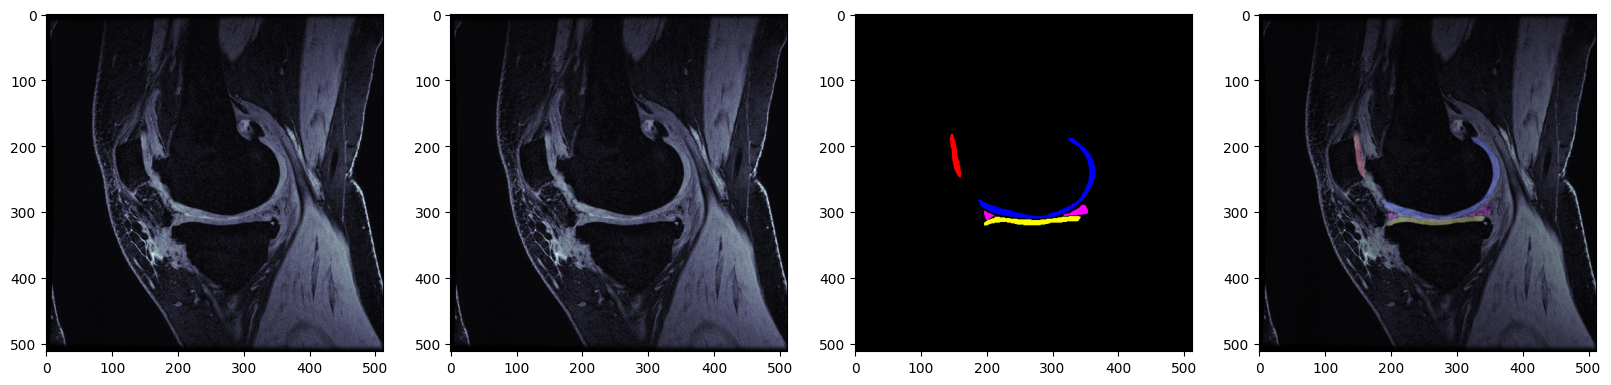

In [19]:
fig, axes = plt.subplots(1, 4, figsize = (20, 20))
axes[0].imshow(echo1, cmap = plt.cm.bone)
axes[1].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[2].imshow(seg_colorized)
axes[3].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[3].imshow(seg_colorized, alpha = 0.2)

# axes[0].axis("off")
# axes[1].axis("off")
# axes[2].axis("off")

In [20]:
cv2.imwrite("skm-tea/MTR_030_100_echo1_scaled.png", echo1_scaled) # save image
cv2.imwrite("skm-tea/MTR_030_100_echo2_scaled.png", echo2_scaled) # save image

True

### look at gz files

In [21]:
import gzip
import shutil
with gzip.open('skm-tea/MTR_030.nii.gz', 'rb') as f_in:
    with open('skm-tea/MTR_030.nii', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

In [22]:
import os
import numpy as np

In [23]:
!pip3 install nibabel

In [24]:
import nibabel as nib

In [25]:
img = nib.load('skm-tea/MTR_030.nii')

In [26]:
# data = img.get_data()

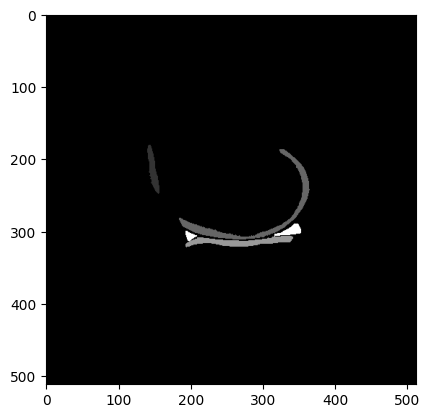

In [27]:
plt.imshow(img.get_fdata()[:, :, 100], cmap='gray')
plt.show()

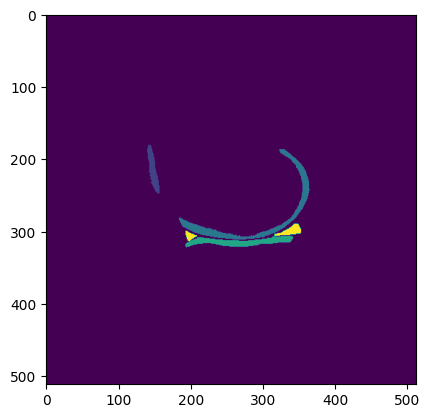

In [28]:
plt.imshow(img.get_fdata()[:, :, 100])

In [29]:
# plt.imshow(cv2.imread("skm-tea/MTR_030_100_nii.png"), cmap='gray')

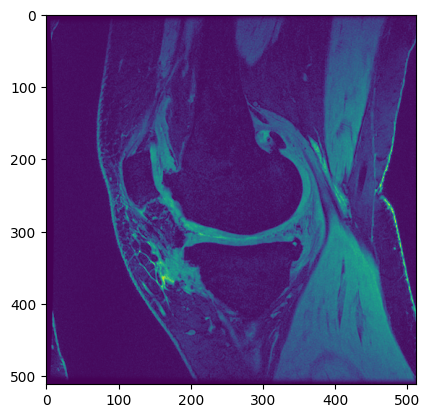

In [30]:
plt.imshow(echo1_scaled)
# cv2.imwrite("skm-tea/MTR_030_100_echo1_scaled.png", echo1_scaled) # save image

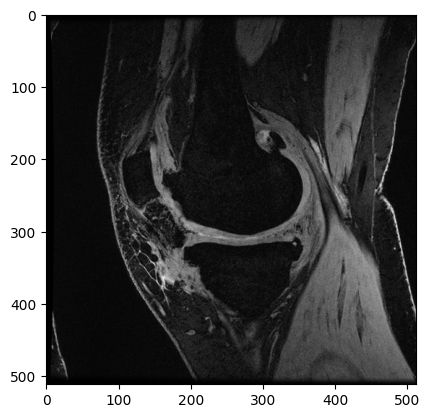

In [31]:
plt.imshow(cv2.imread("skm-tea/MTR_030_100_echo1_scaled.png"))

### Load SAM

In [32]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sam_checkpoint_1 = "sam_vit_h_4b8939.pth"
sam_checkpoint_2 = "sam_vit_b_01ec64.pth"
sam_checkpoint_3 = "sam_vit_l_0b3195.pth"

model_type_1 = "vit_h"
model_type_2 = "vit_b"
model_type_3 = "vit_l"

In [33]:
## set checkpoint & model 
sam_checkpoint_final = sam_checkpoint_2
model_type_final = model_type_2

In [34]:
!pwd
home = '/Users/cindy/Desktop/mids/w210'

/Users/Cindy/Desktop/mids/w210


In [35]:
import os

sam_checkpoint = os.path.join(home, sam_checkpoint_final)
print(sam_checkpoint, "; exist:", os.path.isfile(sam_checkpoint))
model_type = model_type_final

/Users/cindy/Desktop/mids/w210/sam_vit_b_01ec64.pth ; exist: True


In [36]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys

PyTorch version: 2.0.1
Torchvision version: 0.15.2
CUDA is available: False


In [37]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint).to(device=device)

### SAM Predictor with bbox

In [38]:
segmentation.shape

(512, 512)

In [39]:
# segmentation.nonzero()

In [40]:
segmentation = one_hot_to_categorical(seg, channel_dim=-1)

In [41]:
segmentation.nonzero()

(array([182, 182, 182, ..., 320, 320, 321]),
 array([146, 147, 148, ..., 280, 281, 197]))

In [42]:
segmentation[290,344]

5

In [43]:
segmentation

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [44]:
segmentation.shape

(512, 512)

In [45]:
np.unique(segmentation)

array([0, 1, 2, 3, 5])

In [46]:
segmentation_idx_set = [np.argwhere(i==segmentation) for i in np.unique(segmentation)]

In [47]:
len(segmentation_idx_set)

5

In [48]:
segmentation_idx_set[4].shape

(429, 2)

In [49]:
segmentation_idx_set[4][0:5]

array([[290, 344],
       [290, 345],
       [290, 346],
       [290, 347],
       [290, 348]])

In [50]:
segmentation_idx_set[4][0]

array([290, 344])

### SAM with points

In [51]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

In [218]:
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='.', s=marker_size, edgecolor='red', linewidth=0.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='yellow', marker='.', s=marker_size, edgecolor='yellow', linewidth=0.25)  

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

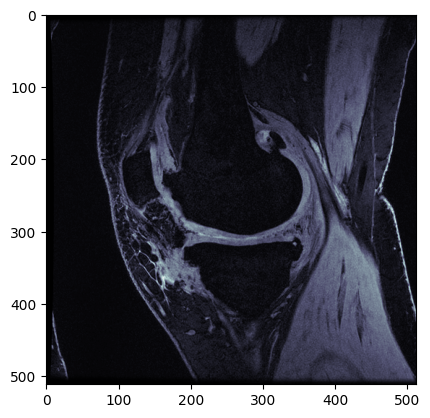

In [214]:
path = 'skm-tea/MTR_030_100_echo1_scaled.png'
img = cv2.imread(path, 0)
# img = echo1_scaled
# plt.imshow(img, cmap='gray')
plt.imshow(img, cmap=plt.cm.bone)

In [54]:
image_array = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
image_array = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

predictor = SamPredictor(sam)
predictor.set_image(image_array)

In [55]:
input_point = np.array([[344, 290]])
input_label = np.array([1])

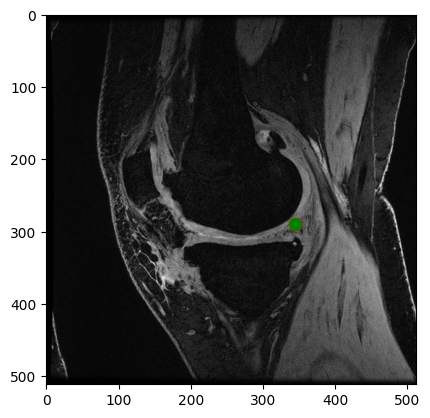

In [56]:
plt.imshow(image_array, cmap = plt.cm.bone)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

In [57]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

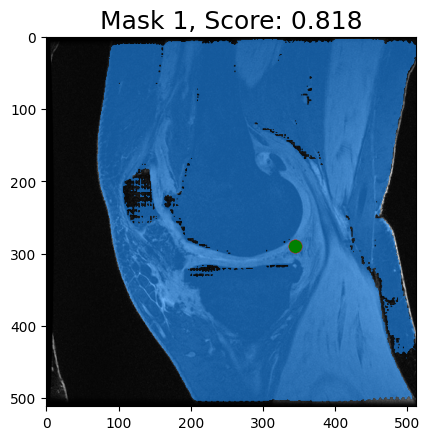

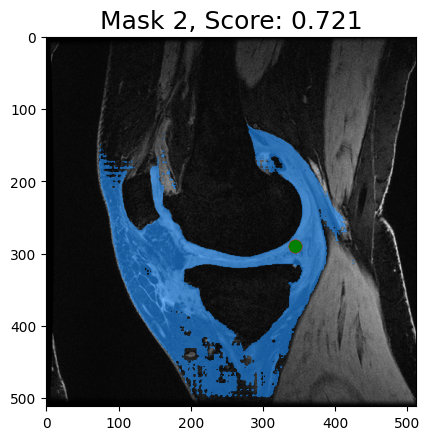

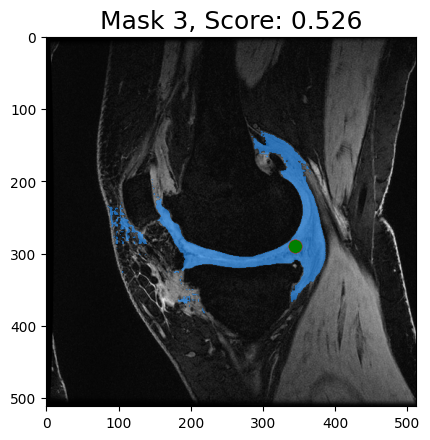

In [58]:

for i, (mask, score) in enumerate(zip(masks, scores)):
#     plt.figure(figsize=(10,10))
    plt.imshow(image_array)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.show()  

### SAM predictor with multiple input points

In [59]:
segmentation.nonzero()

(array([182, 182, 182, ..., 320, 320, 321]),
 array([146, 147, 148, ..., 280, 281, 197]))

In [60]:
segmentation[290, 344]

5

In [61]:
## choose label
print(np.unique(segmentation))
label_idx = 1

[0 1 2 3 5]


In [62]:
segmentation_idx_set[label_idx].shape

(531, 2)

In [63]:
length_of_label = segmentation_idx_set[label_idx].shape[0]

In [64]:
label_5 = [1] * length_of_label

In [65]:
# input_points = np.zeros((length_of_label,2))
input_labels = np.array(label_5)

In [66]:
list_x = [i[1] for i in segmentation_idx_set[label_idx]]
list_y = [i[0] for i in segmentation_idx_set[label_idx]]

input_points = np.array(list(zip(list_x, list_y)))

    # input_points[i][1] = 512 - segmentation_idx_set[2][1]
    # input_points[i][0] = segmentation_idx_set[2][0]

In [67]:
input_points[0:5]

array([[146, 182],
       [147, 182],
       [148, 182],
       [145, 183],
       [146, 183]])

In [68]:
segmentation_idx_set[2][0:5]

array([[188, 324],
       [188, 325],
       [188, 326],
       [188, 327],
       [188, 328]])

In [69]:
# input_points = np.array(segmentation_idx_set[2])

In [70]:
input_points[0][1]

182

In [71]:
input_points.shape

(531, 2)

In [72]:
input_labels.shape

(531,)

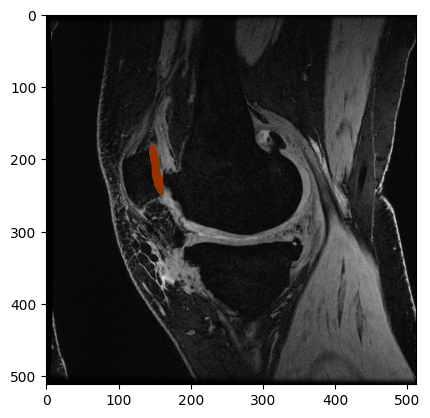

In [73]:
plt.imshow(image_array)
show_points(input_points, input_labels, plt.gca(), marker_size = 10)
plt.axis('on')
plt.show()

In [74]:
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True,
)

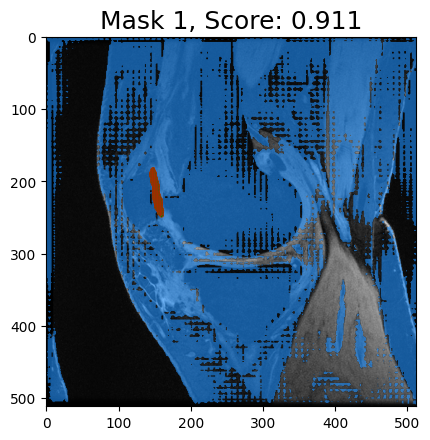

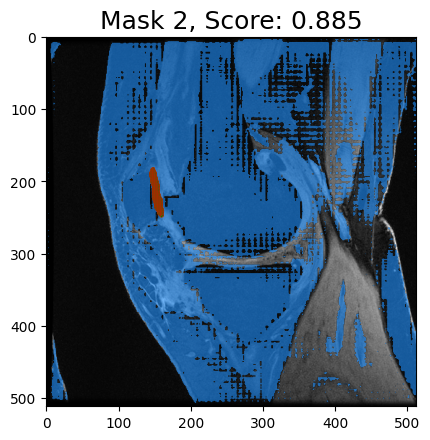

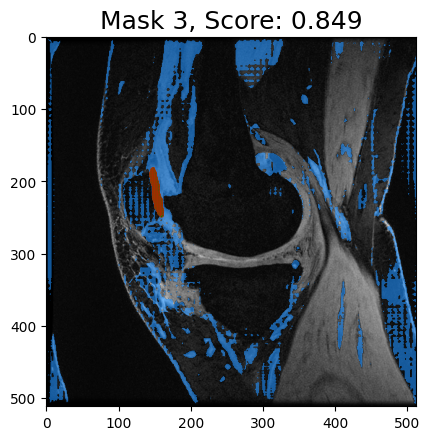

CPU times: user 1.19 s, sys: 27 ms, total: 1.21 s
Wall time: 414 ms


In [75]:
%%time
for i, (mask, score) in enumerate(zip(masks, scores)):
#     plt.figure(figsize=(10,10))
    plt.imshow(image_array)
    show_mask(mask, plt.gca())
    show_points(input_points, input_labels, plt.gca(), marker_size = 10)
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.show()  

### SAM predictor with inclusion & exclusion

In [199]:
exclude_x = [i[1] for i in segmentation_idx_set[0]]
exclude_y = [i[0] for i in segmentation_idx_set[0]]

exclude_points = np.array(list(zip(exclude_x, exclude_y)))

In [200]:
input_labels_ex = np.concatenate((input_labels, [0] * 1000), axis=0)
input_points_ex = input_points

In [201]:
import numpy as np
i = 1
while i <= 1000:
    random_index1 = np.random.randint(0, exclude_points.shape[0])
    new_random = exclude_points[random_index1].reshape(1, 2)  # get the random element
    input_points_ex = np.concatenate((input_points_ex, new_random), axis=0)
    i = i + 1

In [202]:
input_points.shape

(531, 2)

In [203]:
input_points_ex.shape

(1531, 2)

In [204]:
input_labels_ex.shape

(1531,)

In [205]:
input_labels.shape

(531,)

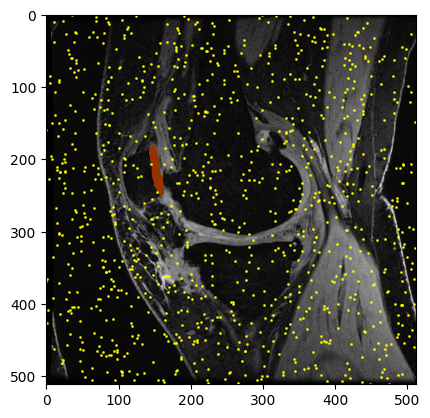

In [219]:
plt.imshow(image_array)
show_points(input_points_ex, input_labels_ex, plt.gca(), marker_size = 10)
plt.axis('on')
plt.show()

In [220]:
%%time
masks, scores, logits = predictor.predict(
    point_coords=input_points_ex,
    point_labels=input_labels_ex,
    multimask_output=True,
)

CPU times: user 1.41 s, sys: 850 ms, total: 2.26 s
Wall time: 696 ms


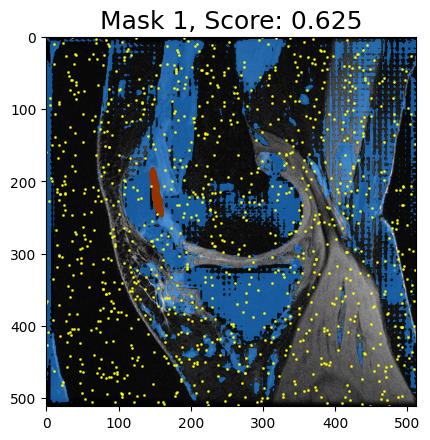

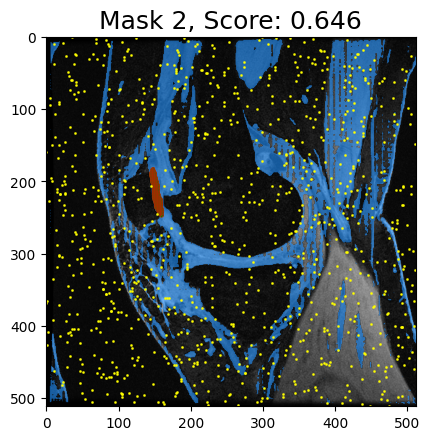

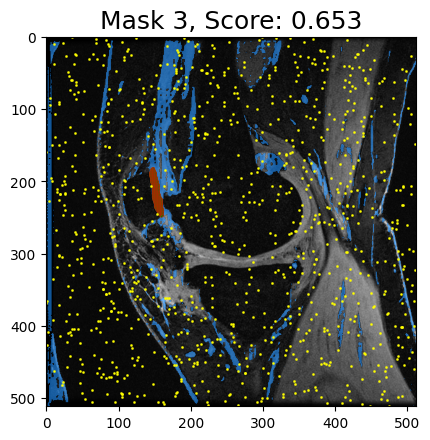

In [221]:
for i, (mask, score) in enumerate(zip(masks, scores)):
#     plt.figure(figsize=(10,10))
    plt.imshow(image_array)
    show_mask(mask, plt.gca())
    show_points(input_points_ex, input_labels_ex, plt.gca(), marker_size = 10)
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.show()

### SAM with bbox

In [ ]:
# input_box = np.array([600, 1100, 2100, 1800])
# masks, _, _ = predictor.predict(
#     point_coords=None,
#     point_labels=None,
#     box=input_box[None, :],
#     multimask_output=False,
# )
# plt.imshow(image_array)
# show_mask(masks[0], plt.gca())
# show_box(input_box, plt.gca())
# plt.show()

In [149]:
# for idx, x in np.ndenumerate(segmentation.nonzero()):
#   print(idx, x)
# for cell in np.nditer(segmentation):
#     dict = {}
# # creates an array of indices, sorted by unique element
# idx_sort = np.argsort(segmentation)

# # sorts records array so all unique elements are together 
# sorted_records_array = records_array[idx_sort]

# # returns the unique values, the index of the first occurrence of a value, and the count for each element
# vals, idx_start, count = np.unique(sorted_records_array, return_counts=True, return_index=True)

# # # splits the indices into separate arrays
# # res = np.split(idx_sort, idx_start[1:])

# # #filter them with respect to their size, keeping only items occurring more than once
# # vals = vals[count > 1]
# # res = filter(lambda x: x.size > 1, res)

In [ ]:
predictor = SamPredictor(sam)
predictor = SamPredictor(sam)

predictor.set_image(<your_image>)
masks, _, _ = predictor.predict(<input_prompts>)


In [ ]:
import cv2
import numpy as np

image_bgr = cv2.imread(IMAGE_PATH)
# image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=box,
    multimask_output=True
)

box = widget.bboxes[0] if widget.bboxes else default_box
box = np.array([
    box['x'], 
    box['y'], 
    box['x'] + box['width'], 
    box['y'] + box['height']
])

In [ ]:
# np.load()